#
# **HR EMPLOYEE ATTRITION ANALYSIS**
# **Analyst  : Krati**
# **Dataset  : Custom HR Dataset (500 employees)**
# **Tools    : Python, Pandas, Matplotlib, Seaborn**
#

### **STEP 1 - IMPORT LIBRARIES**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("=" * 55)
print("   HR EMPLOYEE ATTRITION ANALYSIS")
print("   Analyst: Krati")
print("=" * 55)

   HR EMPLOYEE ATTRITION ANALYSIS
   Analyst: Krati


**STEP 2 -LOADING DATASET**

In [6]:
print("\n📂 STEP 2: Loading Dataset...")

df = pd.read_csv('/content/HR_Employee_Attrition_Dataset.csv')

print(f"✅ Dataset loaded successfully!")
print(f"   Total Rows    : {df.shape[0]}")
print(f"   Total Columns : {df.shape[1]}")
print("\nFirst 5 rows of dataset:")
print(df.head())


📂 STEP 2: Loading Dataset...
✅ Dataset loaded successfully!
   Total Rows    : 500
   Total Columns : 23

First 5 rows of dataset:
  EmployeeID  Age  Gender MaritalStatus     City  Education    EducationField  \
0    EMP1000   50    Male       Married  Kolkata          4             Other   
1    EMP1001   36  Female      Divorced  Chennai          4     Life Sciences   
2    EMP1002   29    Male       Married    Delhi          3     Life Sciences   
3    EMP1003   42    Male       Married     Pune          4  Technical Degree   
4    EMP1004   40  Female       Married  Chennai          3         Marketing   

   Department              JobRole     BusinessTravel  ...  TotalWorkingYears  \
0     Finance      Finance Manager      Travel_Rarely  ...                  3   
1  Operations   Operations Analyst      Travel_Rarely  ...                 18   
2  Operations   Operations Analyst  Travel_Frequently  ...                 15   
3  Operations  Logistics Executive  Travel_Frequently  ..

### **STEP - 3 DATA EXPLORATION**

In [7]:
print("\n" + "=" * 55)
print("📊 STEP 3: Data Exploration")
print("=" * 55)

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Dataset Summary Statistics ---")
print(df.describe())

print("\n--- Missing Values Check ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

print("\n--- Duplicate Rows Check ---")
dupes = df.duplicated().sum()
print(f"✅ Duplicate rows: {dupes}")


📊 STEP 3: Data Exploration

--- Column Names & Data Types ---
EmployeeID                 object
Age                         int64
Gender                     object
MaritalStatus              object
City                       object
Education                   int64
EducationField             object
Department                 object
JobRole                    object
BusinessTravel             object
MonthlyIncome               int64
YearsAtCompany              int64
YearsInCurrentRole          int64
TotalWorkingYears           int64
NumCompaniesWorked          int64
DistanceFromHome            int64
OverTime                   object
JobSatisfaction             int64
WorkLifeBalance             int64
EnvironmentSatisfaction     int64
PerformanceRating           int64
TrainingTimesLastYear       int64
Attrition                  object
dtype: object

--- Dataset Summary Statistics ---
              Age   Education  MonthlyIncome  YearsAtCompany  \
count  500.000000  500.000000      500.00

### **STEP - 4 DATA CLEANING**

In [8]:
print("\n" + "=" * 55)
print("🧹 STEP 4: Data Cleaning")
print("=" * 55)

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Remove nulls if any
df.dropna(inplace=True)

# Convert Attrition to binary for calculations
df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Income Brackets
df['Income_Bracket'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 30000, 50000, 75000, 200000],
    labels=['Below 30K', '30K-50K', '50K-75K', 'Above 75K']
)

# Age Groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60']
)

print("✅ Data cleaning complete!")
print(f"   Final Dataset Size: {df.shape[0]} rows × {df.shape[1]} columns")


🧹 STEP 4: Data Cleaning
✅ Data cleaning complete!
   Final Dataset Size: 500 rows × 26 columns


### **STEP 5- KEY BUSINESS METRICS**

In [9]:
print("\n" + "=" * 55)
print("📈 STEP 5: Key Business Metrics")
print("=" * 55)

total_emp        = len(df)
total_attrition  = df['Attrition_Flag'].sum()
attrition_rate   = round((total_attrition / total_emp) * 100, 2)
avg_salary       = round(df['MonthlyIncome'].mean(), 0)
avg_age          = round(df['Age'].mean(), 1)
avg_years        = round(df['YearsAtCompany'].mean(), 1)

print(f"\n  👥 Total Employees     : {total_emp}")
print(f"  🚪 Employees Left      : {total_attrition}")
print(f"  📉 Attrition Rate      : {attrition_rate}%")
print(f"  💰 Average Salary      : ₹{avg_salary:,.0f}")
print(f"  🎂 Average Age         : {avg_age} years")
print(f"  🏢 Avg Years at Company: {avg_years} years")


📈 STEP 5: Key Business Metrics

  👥 Total Employees     : 500
  🚪 Employees Left      : 151
  📉 Attrition Rate      : 30.2%
  💰 Average Salary      : ₹65,101
  🎂 Average Age         : 40.4 years
  🏢 Avg Years at Company: 10.1 years


### **STEP 6 - CREATING VISUALIZATION**

In [10]:
print("\n" + "=" * 55)
print("🎨 STEP 6: Creating Visualizations...")
print("=" * 55)

colors_yn   = ['#2ecc71', '#e74c3c']
main_color  = '#3498db'
accent      = '#e74c3c'


🎨 STEP 6: Creating Visualizations...


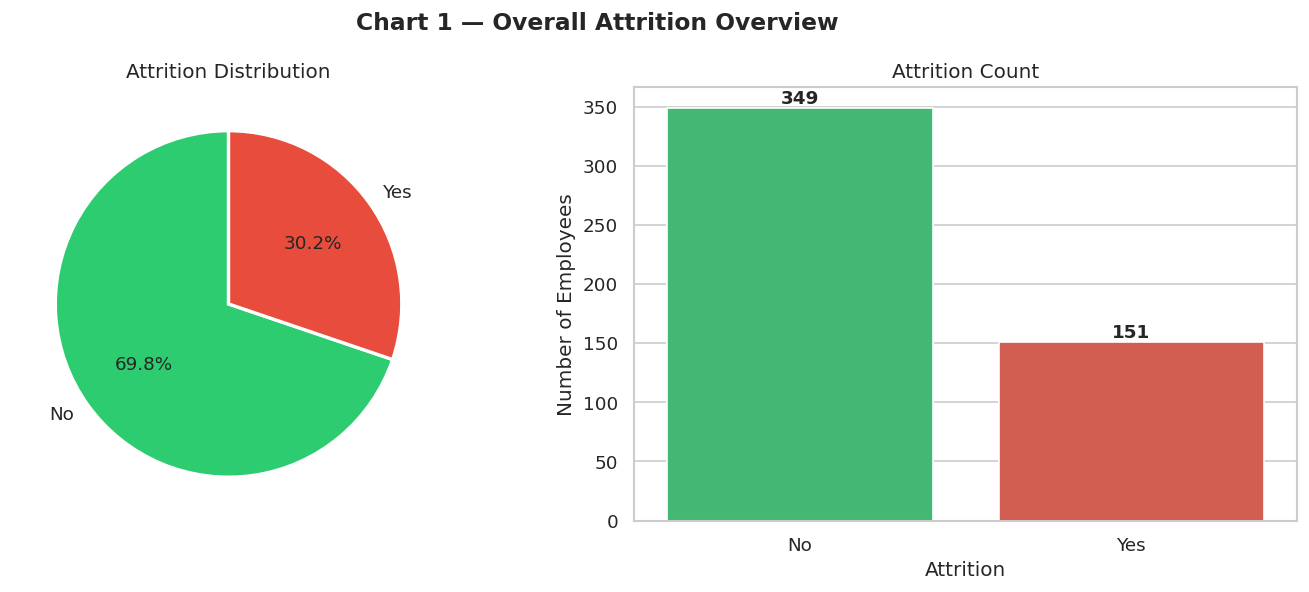

✅ Chart 1 saved and displayed — Overall Attrition


In [11]:
# --- CHART 1: Ove---rall Attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 1 — Overall Attrition Overview', fontsize=14, fontweight='bold')

counts = df['Attrition'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors_yn, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Attrition Distribution')

sns.countplot(x='Attrition', data=df, palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[1])
axes[1].set_title('Attrition Count')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Number of Employees')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/chart1_overall_attrition.png', bbox_inches='tight')
plt.show()  # Changed from plt.close() to plt.show() to display the graph
print("✅ Chart 1 saved and displayed — Overall Attrition")

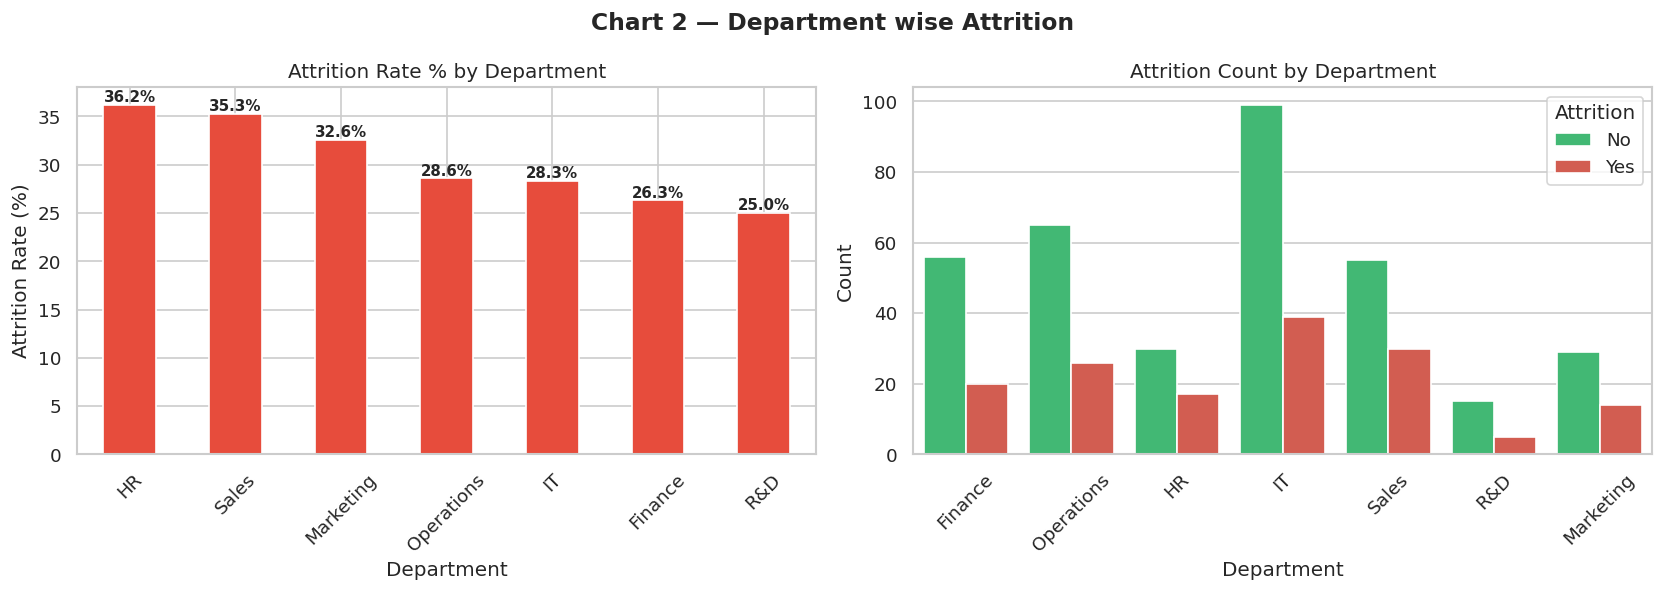

✅ Chart 2 saved and displayed — Department Attrition


In [12]:
# --- CHART 2: Department wise Attrition ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 2 — Department wise Attrition', fontsize=14, fontweight='bold')

dept_attr = df.groupby('Department')['Attrition_Flag'].agg(['sum', 'count'])
dept_attr['Rate'] = round((dept_attr['sum'] / dept_attr['count']) * 100, 1)
dept_attr = dept_attr.sort_values('Rate', ascending=False)

dept_attr['Rate'].plot(kind='bar', color=accent, ax=axes[0], edgecolor='white')
axes[0].set_title('Attrition Rate % by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(dept_attr['Rate']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=9)

sns.countplot(x='Department', hue='Attrition', data=df,
              palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[1])
axes[1].set_title('Attrition Count by Department')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/chart2_department_attrition.png', bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved and displayed — Department Attrition")

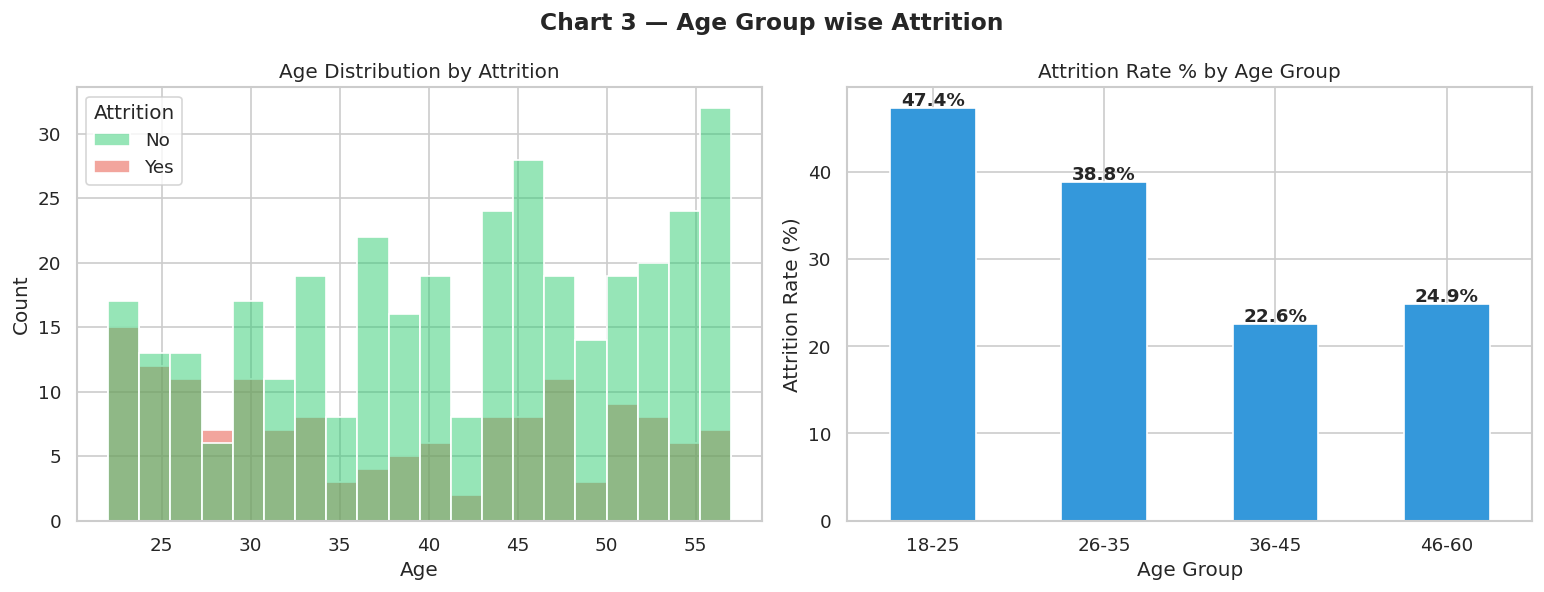

✅ Chart 3 saved and displayed — Age Group Attrition


In [13]:
# --- CHART 3: Age Group Attrition ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 3 — Age Group wise Attrition', fontsize=14, fontweight='bold')

sns.histplot(data=df, x='Age', hue='Attrition',
             palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
             bins=20, ax=axes[0])
axes[0].set_title('Age Distribution by Attrition')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

age_attr = df.groupby('Age_Group')['Attrition_Flag'].mean() * 100
age_attr.plot(kind='bar', color=main_color, ax=axes[1], edgecolor='white')
axes[1].set_title('Attrition Rate % by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(age_attr):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
# Fixed path from /home/claude/ to /content/
plt.savefig('/content/chart3_age_attrition.png', bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved and displayed — Age Group Attrition")

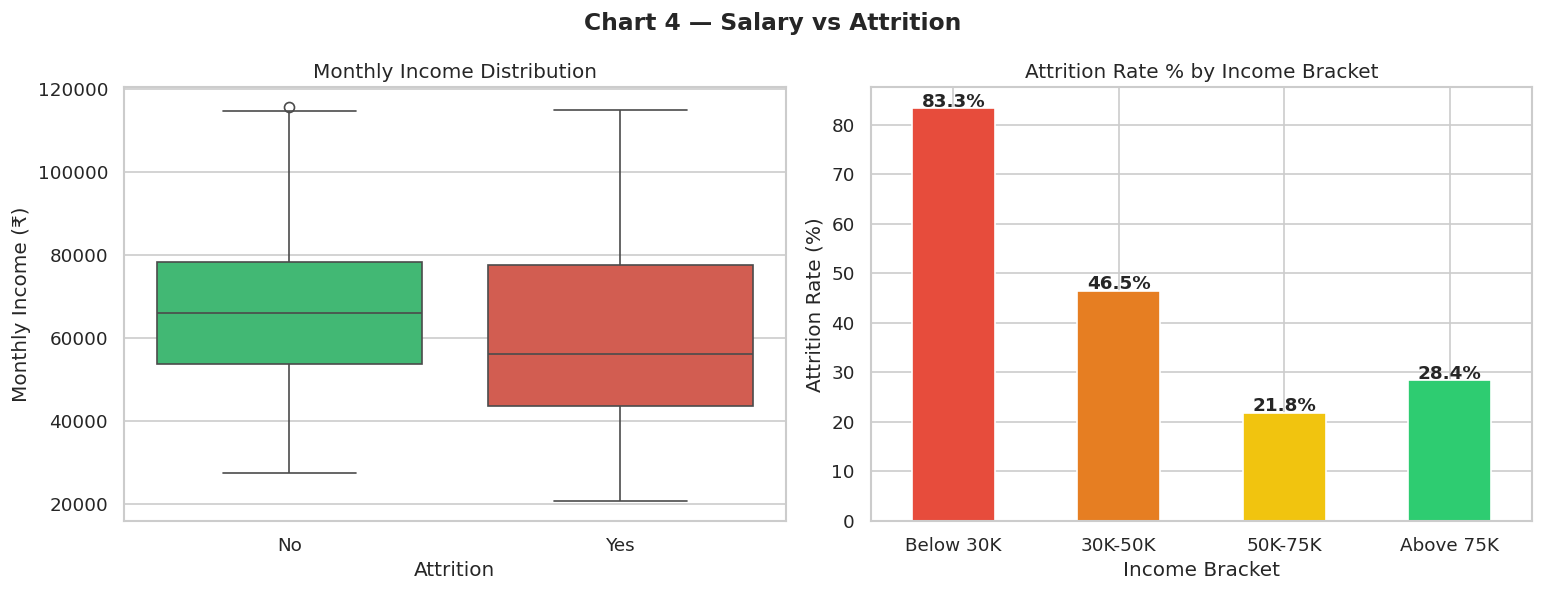

✅ Chart 4 saved and displayed — Salary Attrition


In [14]:
# --- CHART 4: Salary vs Attrition ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 4 — Salary vs Attrition', fontsize=14, fontweight='bold')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Monthly Income Distribution')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income (₹)')

inc_attr = df.groupby('Income_Bracket')['Attrition_Flag'].mean() * 100
inc_attr.plot(kind='bar', color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'], ax=axes[1], edgecolor='white')
axes[1].set_title('Attrition Rate % by Income Bracket')
axes[1].set_xlabel('Income Bracket')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(inc_attr):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
# Fixed path from /home/claude/ to /content/ and changed close() to show()
plt.savefig('/content/chart4_salary_attrition.png', bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved and displayed — Salary Attrition")

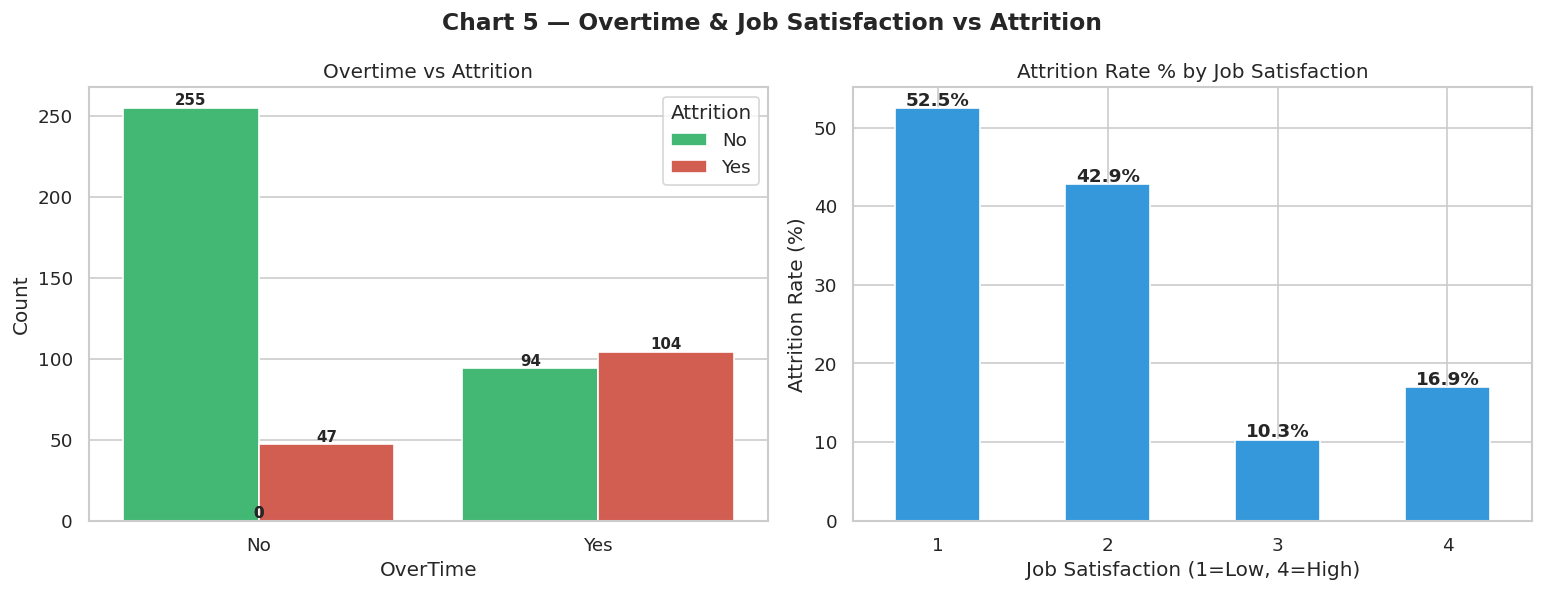

✅ Chart 5 saved and displayed — Overtime & Satisfaction


In [15]:
# --- CHART 5: Overtime & Job Satisfaction ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 5 — Overtime & Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')

sns.countplot(x='OverTime', hue='Attrition', data=df,
              palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Overtime vs Attrition')
axes[0].set_xlabel('OverTime')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

sat_attr = df.groupby('JobSatisfaction')['Attrition_Flag'].mean() * 100
sat_attr.plot(kind='bar', color=main_color, ax=axes[1], edgecolor='white')
axes[1].set_title('Attrition Rate % by Job Satisfaction')
axes[1].set_xlabel('Job Satisfaction (1=Low, 4=High)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(sat_attr):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
# Fixed path from /home/claude/ to /content/ and changed close() to show()
plt.savefig('/content/chart5_overtime_satisfaction.png', bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved and displayed — Overtime & Satisfaction")

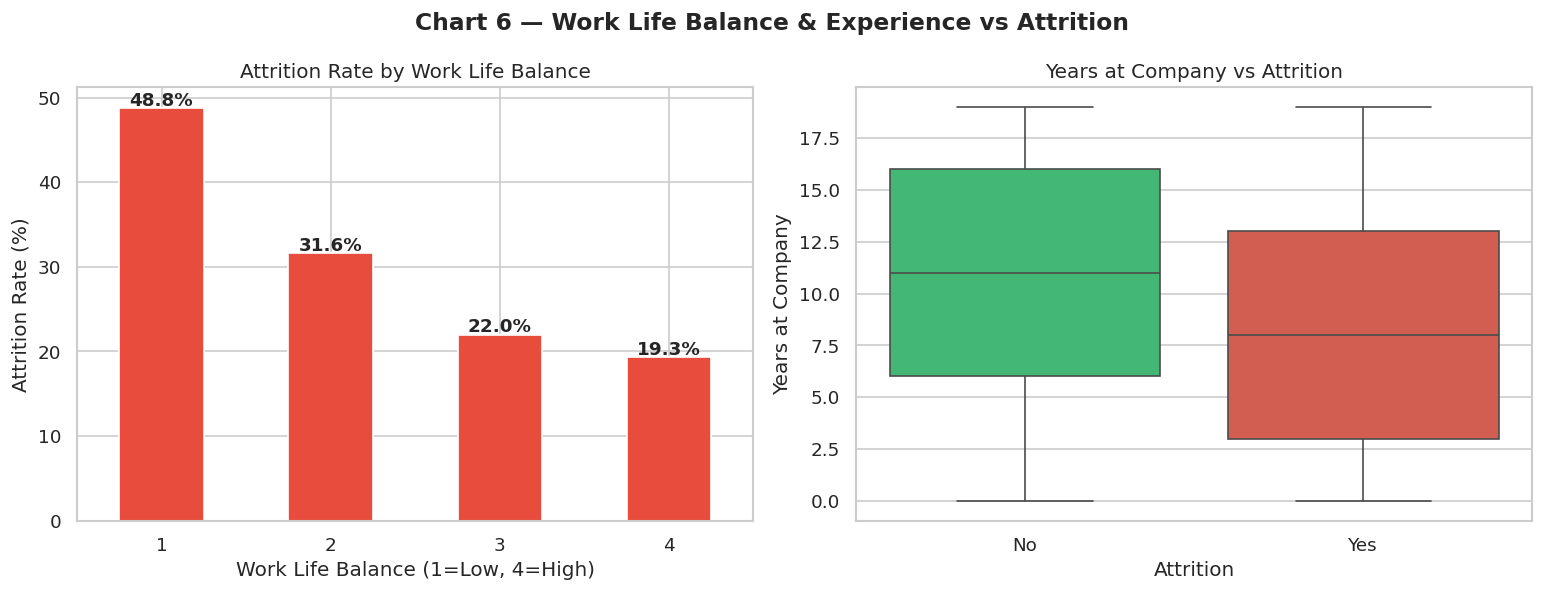

✅ Chart 6 saved and displayed — Work Life Balance & Experience


In [16]:
# --- CHART 6: Work Life Balance & Years at Company ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 6 — Work Life Balance & Experience vs Attrition', fontsize=14, fontweight='bold')

wlb_attr = df.groupby('WorkLifeBalance')['Attrition_Flag'].mean() * 100
wlb_attr.plot(kind='bar', color=accent, ax=axes[0], edgecolor='white')
axes[0].set_title('Attrition Rate by Work Life Balance')
axes[0].set_xlabel('Work Life Balance (1=Low, 4=High)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(wlb_attr):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df,
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[1])
axes[1].set_title('Years at Company vs Attrition')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Years at Company')

plt.tight_layout()
# Fixed path from /home/claude/ to /content/ and changed close() to show()
plt.savefig('/content/chart6_wlb_experience.png', bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved and displayed — Work Life Balance & Experience")

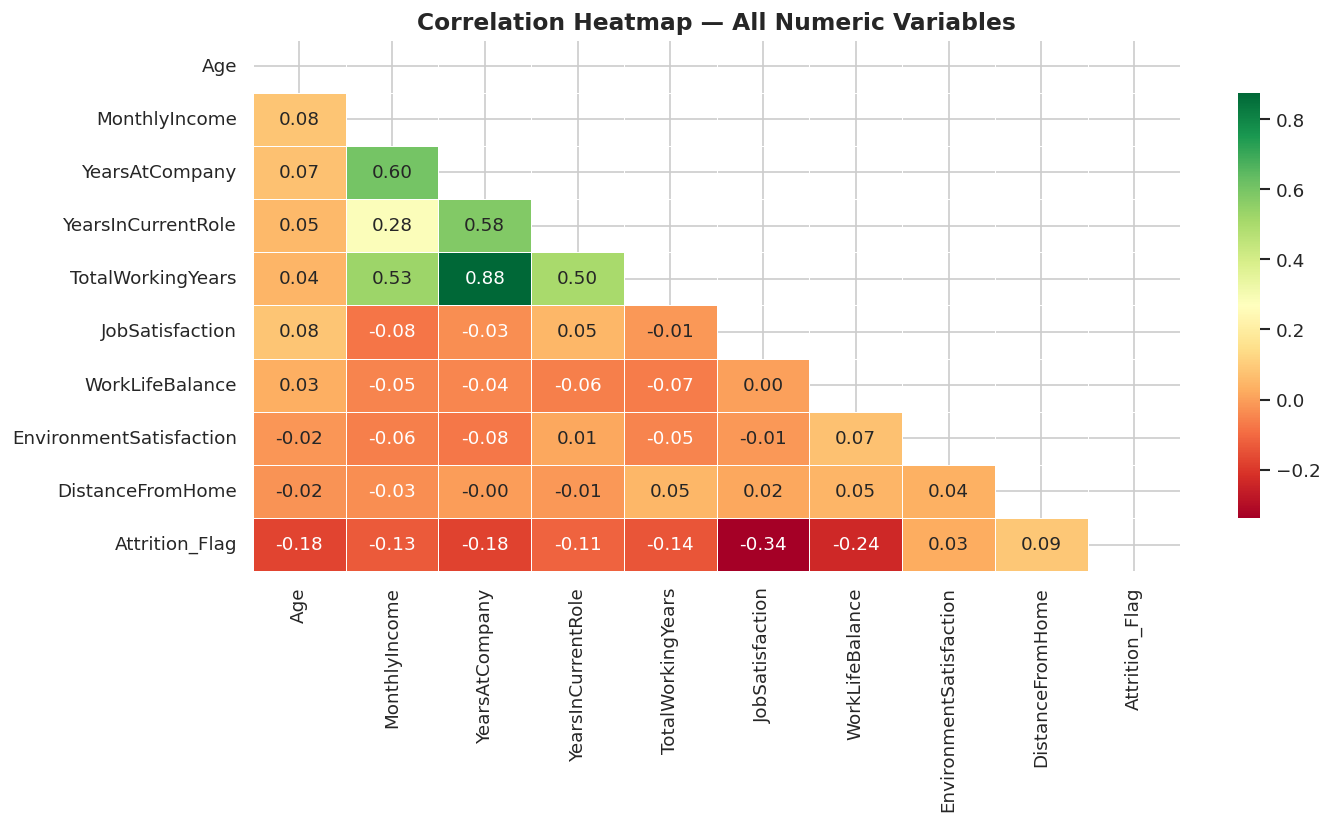

✅ Chart 7 saved and displayed — Correlation Heatmap


In [17]:
# --- CHART 7: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(12, 7))
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole',
                'TotalWorkingYears', 'JobSatisfaction', 'WorkLifeBalance',
                'EnvironmentSatisfaction', 'DistanceFromHome', 'Attrition_Flag']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — All Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
# Fixed path from /home/claude/ to /content/ and changed close() to show()
plt.savefig('/content/chart7_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved and displayed — Correlation Heatmap")

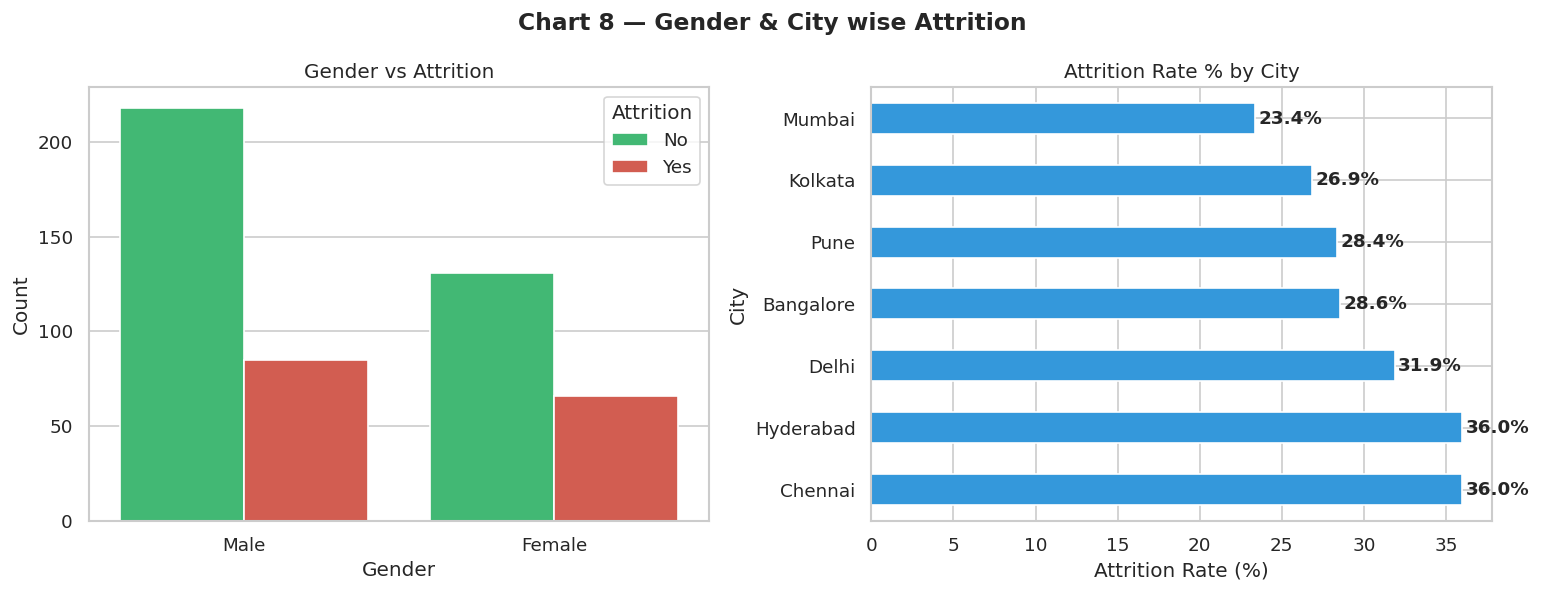

✅ Chart 8 saved and displayed — Gender & City Attrition


In [18]:
# --- CHART 8: Gender & City wise Attrition ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 8 — Gender & City wise Attrition', fontsize=14, fontweight='bold')

sns.countplot(x='Gender', hue='Attrition', data=df,
              palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Gender vs Attrition')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

city_attr = df.groupby('City')['Attrition_Flag'].mean() * 100
city_attr = city_attr.sort_values(ascending=False)
city_attr.plot(kind='barh', color=main_color, ax=axes[1], edgecolor='white')
axes[1].set_title('Attrition Rate % by City')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_ylabel('City')
for i, v in enumerate(city_attr):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
# Fixed path from /home/claude/ to /content/ and changed close() to show()
plt.savefig('/content/chart8_gender_city.png', bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved and displayed — Gender & City Attrition")

### **STEP 7 - KEY INSIGHTS**

In [19]:
# STEP 7 — KEY INSIGHTS
# -------------------------------------------------------
print("\n" + "=" * 55)
print("💡 STEP 7: Key Business Insights")
print("=" * 55)

# Calculate insights dynamically
top_dept = dept_attr['Rate'].idxmax()
top_dept_rate = dept_attr['Rate'].max()

ot_yes_rate = round(df[df['OverTime'] == 'Yes']['Attrition_Flag'].mean() * 100, 1)
ot_no_rate  = round(df[df['OverTime'] == 'No']['Attrition_Flag'].mean() * 100, 1)

low_sal_rate  = round(df[df['Income_Bracket'] == 'Below 30K']['Attrition_Flag'].mean() * 100, 1)
high_sal_rate = round(df[df['Income_Bracket'] == 'Above 75K']['Attrition_Flag'].mean() * 100, 1)

low_sat_rate  = round(df[df['JobSatisfaction'] == 1]['Attrition_Flag'].mean() * 100, 1)
high_sat_rate = round(df[df['JobSatisfaction'] == 4]['Attrition_Flag'].mean() * 100, 1)

young_rate = round(df[df['Age_Group'] == '18-25']['Attrition_Flag'].mean() * 100, 1)

print(f"""
  📌 INSIGHT 1 — Overall Attrition Rate
     {attrition_rate}% of employees left the company
     ({total_attrition} out of {total_emp} employees)

  📌 INSIGHT 2 — Department Risk
     {top_dept} department has the HIGHEST attrition
     rate at {top_dept_rate}%

  📌 INSIGHT 3 — Overtime Impact
     Employees doing overtime leave at {ot_yes_rate}% rate
     vs only {ot_no_rate}% for those without overtime

  📌 INSIGHT 4 — Salary Impact
     Low salary (Below ₹30K) → {low_sal_rate}% attrition rate
     High salary (Above ₹75K) → {high_sal_rate}% attrition rate

  📌 INSIGHT 5 — Job Satisfaction
     Low satisfaction (Score 1) → {low_sat_rate}% attrition
     High satisfaction (Score 4) → {high_sat_rate}% attrition

  📌 INSIGHT 6 — Young Employees at Risk
     Age group 18-25 has {young_rate}% attrition rate
     (Youngest employees leave the most)
""")



💡 STEP 7: Key Business Insights

  📌 INSIGHT 1 — Overall Attrition Rate
     30.2% of employees left the company
     (151 out of 500 employees)

  📌 INSIGHT 2 — Department Risk
     HR department has the HIGHEST attrition
     rate at 36.2%

  📌 INSIGHT 3 — Overtime Impact
     Employees doing overtime leave at 52.5% rate
     vs only 15.6% for those without overtime

  📌 INSIGHT 4 — Salary Impact
     Low salary (Below ₹30K) → 83.3% attrition rate
     High salary (Above ₹75K) → 28.4% attrition rate

  📌 INSIGHT 5 — Job Satisfaction
     Low satisfaction (Score 1) → 52.5% attrition
     High satisfaction (Score 4) → 16.9% attrition

  📌 INSIGHT 6 — Young Employees at Risk
     Age group 18-25 has 47.4% attrition rate
     (Youngest employees leave the most)



### **STEP 8 - RECOMMENDATIONS**

In [20]:
# -------------------------------------------------------
# STEP 8 — RECOMMENDATIONS
# -------------------------------------------------------
print("=" * 55)
print("✅ STEP 8: Business Recommendations")
print("=" * 55)
print(f"""
  1. SALARY REVIEW
     Increase salaries for employees below ₹30,000
     This will reduce attrition significantly

  2. OVERTIME POLICY
     Limit overtime or give compensation/bonus
     Employees doing overtime are leaving more

  3. FOCUS ON {top_dept.upper()} DEPARTMENT
     Highest attrition — conduct exit interviews
     Understand root cause and fix it urgently

  4. YOUNG EMPLOYEE RETENTION
     Create mentorship programs for age 18-25
     Provide career growth and learning opportunities

  5. JOB SATISFACTION SURVEYS
     Conduct quarterly satisfaction surveys
     Act on low scores immediately
""")

print("=" * 55)
print("🎉 PROJECT COMPLETE — HR Employee Attrition Analysis")
print("   All 8 charts saved successfully!")
print("   Analyst: Krati")
print("=" * 55)

✅ STEP 8: Business Recommendations

  1. SALARY REVIEW
     Increase salaries for employees below ₹30,000
     This will reduce attrition significantly

  2. OVERTIME POLICY
     Limit overtime or give compensation/bonus
     Employees doing overtime are leaving more

  3. FOCUS ON HR DEPARTMENT
     Highest attrition — conduct exit interviews
     Understand root cause and fix it urgently

  4. YOUNG EMPLOYEE RETENTION
     Create mentorship programs for age 18-25
     Provide career growth and learning opportunities

  5. JOB SATISFACTION SURVEYS
     Conduct quarterly satisfaction surveys
     Act on low scores immediately

🎉 PROJECT COMPLETE — HR Employee Attrition Analysis
   All 8 charts saved successfully!
   Analyst: Krati
